In [1]:
!pip install -q transformers datasets accelerate scikit-learn pandas matplotlib seaborn

In [4]:
import pandas as pd
import numpy as np
import torch
import os

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer
)

print("PyTorch:", torch.__version__)
print("GPU available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

PyTorch: 2.11.0+cu128
GPU available: True
GPU: Tesla T4


In [3]:
from google.colab import drive

drive.mount('/content/drive')

Mounted at /content/drive


In [6]:
import pandas as pd

file_path = '/content/drive/My Drive/DS 340W/dataset.csv'

df = pd.read_csv(file_path)

print("Dataset shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

display(df.head())

Dataset shape: (6420, 3)

Columns:
['id', 'tweet', 'label']


,id,tweet,label
0,1,The CDC currently reports 99031 deaths. In gen...,real
1,2,States reported 1121 deaths a small rise from ...,real
2,3,Politically Correct Woman (Almost) Uses Pandem...,fake
3,4,#IndiaFightsCorona: We have 1524 #COVID testin...,real
4,5,Populous states can generate large case counts...,real


In [7]:
print("Dataset shape:", df.shape)

print("\nColumn names:")
print(df.columns.tolist())

print("\nFirst 5 rows:")
display(df.head())

print("\nDataset information:")
df.info()

Dataset shape: (6420, 3)

Column names:
['id', 'tweet', 'label']

First 5 rows:


,id,tweet,label
0,1,The CDC currently reports 99031 deaths. In gen...,real
1,2,States reported 1121 deaths a small rise from ...,real
2,3,Politically Correct Woman (Almost) Uses Pandem...,fake
3,4,#IndiaFightsCorona: We have 1524 #COVID testin...,real
4,5,Populous states can generate large case counts...,real



Dataset information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6420 entries, 0 to 6419
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   id      6420 non-null   int64 
 1   tweet   6420 non-null   object
 2   label   6420 non-null   object
dtypes: int64(1), object(2)
memory usage: 150.6+ KB


In [8]:
print("Unique labels:")
print(df.iloc[:, -1].unique())

print("\nLabel counts:")
print(df.iloc[:, -1].value_counts())

Unique labels:
['real' 'fake']

Label counts:
label
real    3360
fake    3060
Name: count, dtype: int64


In [9]:
# Convert labels to numerical values
df["label"] = df["label"].map({
    "fake": 0,
    "real": 1
})

# Verify the conversion
print(df["label"].value_counts())
print("\nUnique labels:", df["label"].unique())

label
1    3360
0    3060
Name: count, dtype: int64

Unique labels: [1 0]


In [12]:

# Change this folder path if your CSVs are in a different folder
folder_path = "/content/drive/My Drive/DS 340W/"

train_df = pd.read_csv(folder_path + "train.csv")
validation_df = pd.read_csv(folder_path + "validation.csv")
test_df = pd.read_csv(folder_path + "test.csv")

print("Training data:", train_df.shape)
print("Validation data:", validation_df.shape)
print("Testing data:", test_df.shape)

Training data: (4494, 3)
Validation data: (642, 3)
Testing data: (1284, 3)


In [13]:
print("TRAINING DATA")
display(train_df.head())

print("\nVALIDATION DATA")
display(validation_df.head())

print("\nTESTING DATA")
display(test_df.head())

TRAINING DATA


,id,tweet,label
0,477,The novel coronavirus can be cured by one bowl...,fake
1,2434,At the peak in New York on April 15 that state...,real
2,4689,Video shows a huge crowd gathered in an Americ...,fake
3,5106,(2/4) Containment zones that refer to a specif...,real
4,2635,Australian Scientists referred to coronavirus ...,fake



VALIDATION DATA


,id,tweet,label
0,3257,Homeopathic drug ‘Arsenicum album 30’ for prev...,fake
1,982,A dog was quarantined in Hong Kong after testi...,fake
2,2679,226 new cases of #COVID19; 131-Lagos 25-Ogun 1...,real
3,1243,It should be obvious now but the large numbers...,real
4,573,Says Tom Hanks has a volleyball to keep him co...,fake



TESTING DATA


,id,tweet,label
0,5731,#COVID19 and seasonal #allergies share many sy...,real
1,1265,COVID-19 is a “strain of the flu”,fake
2,4789,#IndiaFightsCorona Early identification follow...,real
3,6119,NEWS! More COVID-19 sorrow as Audi drivers in ...,fake
4,1314,Today's update is the first produced by a team...,real


In [14]:
print("Training labels:")
print(train_df["label"].value_counts())

print("\nValidation labels:")
print(validation_df["label"].value_counts())

print("\nTest labels:")
print(test_df["label"].value_counts())

Training labels:
label
real    2352
fake    2142
Name: count, dtype: int64

Validation labels:
label
real    336
fake    306
Name: count, dtype: int64

Test labels:
label
real    672
fake    612
Name: count, dtype: int64


In [15]:
# Convert labels to numerical values
label_map = {
    "fake": 0,
    "real": 1
}

train_df["label"] = train_df["label"].map(label_map)
validation_df["label"] = validation_df["label"].map(label_map)
test_df["label"] = test_df["label"].map(label_map)

# Verify
print("Training labels:")
print(train_df["label"].value_counts())

print("\nValidation labels:")
print(validation_df["label"].value_counts())

print("\nTesting labels:")
print(test_df["label"].value_counts())

Training labels:
label
1    2352
0    2142
Name: count, dtype: int64

Validation labels:
label
1    336
0    306
Name: count, dtype: int64

Testing labels:
label
1    672
0    612
Name: count, dtype: int64


In [16]:
# Make sure the labels are integers
train_df["label"] = train_df["label"].astype(int)
validation_df["label"] = validation_df["label"].astype(int)
test_df["label"] = test_df["label"].astype(int)

# Extract tweets and labels
train_texts = train_df["tweet"].astype(str).tolist()
train_labels = train_df["label"].tolist()

validation_texts = validation_df["tweet"].astype(str).tolist()
validation_labels = validation_df["label"].tolist()

test_texts = test_df["tweet"].astype(str).tolist()
test_labels = test_df["label"].tolist()

print("Training:", len(train_texts))
print("Validation:", len(validation_texts))
print("Testing:", len(test_texts))

Training: 4494
Validation: 642
Testing: 1284


In [17]:
from transformers import AutoTokenizer, AutoModelForSequenceClassification

MODEL_NAME = "distilbert-base-uncased"

# Load the tokenizer
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

# Load the pretrained DistilBERT model
model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=2
)

print("DistilBERT tokenizer and model loaded successfully!")

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  268MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
pre_classifier.bias     | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.bias         | MISSING    | 
classifier.weight       | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


DistilBERT tokenizer and model loaded successfully!


In [18]:
# Maximum number of tokens for each tweet
MAX_LENGTH = 128

# Tokenize training data
train_encodings = tokenizer(
    train_texts,
    truncation=True,
    padding=True,
    max_length=MAX_LENGTH
)

# Tokenize validation data
validation_encodings = tokenizer(
    validation_texts,
    truncation=True,
    padding=True,
    max_length=MAX_LENGTH
)

# Tokenize testing data
test_encodings = tokenizer(
    test_texts,
    truncation=True,
    padding=True,
    max_length=MAX_LENGTH
)

print("Tokenization complete!")

print("Training examples:", len(train_encodings["input_ids"]))
print("Validation examples:", len(validation_encodings["input_ids"]))
print("Testing examples:", len(test_encodings["input_ids"]))

Tokenization complete!
Training examples: 4494
Validation examples: 642
Testing examples: 1284


In [19]:
import torch

class FakeNewsDataset(torch.utils.data.Dataset):

    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = labels

    def __getitem__(self, idx):
        item = {
            key: torch.tensor(value[idx])
            for key, value in self.encodings.items()
        }

        item["labels"] = torch.tensor(
            self.labels[idx],
            dtype=torch.long
        )

        return item

    def __len__(self):
        return len(self.labels)


# Create datasets
train_dataset = FakeNewsDataset(
    train_encodings,
    train_labels
)

validation_dataset = FakeNewsDataset(
    validation_encodings,
    validation_labels
)

test_dataset = FakeNewsDataset(
    test_encodings,
    test_labels
)

print("Training dataset:", len(train_dataset))
print("Validation dataset:", len(validation_dataset))
print("Testing dataset:", len(test_dataset))

Training dataset: 4494
Validation dataset: 642
Testing dataset: 1284


In [20]:
import numpy as np
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

def compute_metrics(eval_pred):
    predictions, labels = eval_pred

    # Convert model outputs into predicted class
    predictions = np.argmax(predictions, axis=1)

    accuracy = accuracy_score(labels, predictions)
    precision = precision_score(labels, predictions, zero_division=0)
    recall = recall_score(labels, predictions, zero_division=0)
    f1 = f1_score(labels, predictions, zero_division=0)

    return {
        "accuracy": accuracy,
        "precision": precision,
        "recall": recall,
        "f1": f1
    }

print("Metrics ready!")

Metrics ready!


In [21]:
from transformers import TrainingArguments

training_args = TrainingArguments(
    output_dir="./distilbert_results",

    # Evaluate using our validation dataset
    eval_strategy="epoch",

    # Save the model after each epoch
    save_strategy="epoch",

    # Learning rate for fine-tuning
    learning_rate=2e-5,

    # Number of tweets processed at once
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,

    # Train for 3 passes through the training data
    num_train_epochs=3,

    # Helps prevent overfitting
    weight_decay=0.01,

    # Keep the model with the best validation F1
    load_best_model_at_end=True,
    metric_for_best_model="f1",

    # Don't send logs to external services
    report_to="none"
)

print("Training configuration ready!")

Training configuration ready!


In [22]:
from transformers import Trainer

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=validation_dataset,
    compute_metrics=compute_metrics
)

print("Trainer ready!")

Trainer ready!


In [23]:
train_result = trainer.train()

Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,No log,0.129436,0.956386,0.950292,0.967262,0.958702
2,0.180519,0.107512,0.971963,0.962209,0.985119,0.973529
3,0.180519,0.104196,0.971963,0.964912,0.982143,0.973451


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

In [24]:
test_results = trainer.evaluate(
    eval_dataset=test_dataset
)

print("\nFINAL DISTILBERT TEST RESULTS")
print("--------------------------------")

for key, value in test_results.items():
    if isinstance(value, float):
        print(f"{key}: {value:.4f}")
    else:
        print(f"{key}: {value}")

Training Loss,Validation Loss,Epoch,Accuracy,Precision,Recall,F1
0.180519,0.109747,3,0.966511,0.963181,0.973214,0.968172



FINAL DISTILBERT TEST RESULTS
--------------------------------
eval_loss: 0.1097
eval_accuracy: 0.9665
eval_precision: 0.9632
eval_recall: 0.9732
eval_f1: 0.9682


In [25]:
from sklearn.metrics import confusion_matrix
import numpy as np

# Get predictions on the test set
predictions = trainer.predict(test_dataset)

# Convert model outputs to predicted labels
predicted_labels = np.argmax(predictions.predictions, axis=1)

# Actual labels
true_labels = np.array(test_labels)

# Create confusion matrix
cm = confusion_matrix(true_labels, predicted_labels)

print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[587  25]
 [ 18 654]]


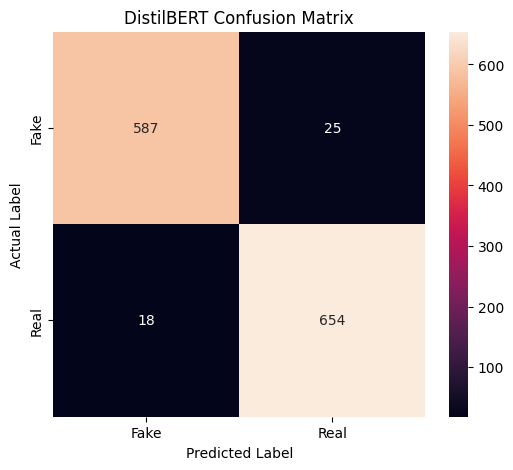

In [26]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=["Fake", "Real"],
    yticklabels=["Fake", "Real"]
)

plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.title("DistilBERT Confusion Matrix")

plt.show()